# 05 - Comprehensive SHAP Model Explanation

**Non-redundant SHAP figures** (all 600 DPI PDF):
- **Polar bee-swarm** (1x3): consolidated overview - inner bar = importance, outer dots = distribution
- **Dependence** (1x3): SHAP(x) functional form - nonlinearities, thresholds, saturation
- **Waterfall** (per target): individual prediction decomposition for median sample
- **Cross-target combined** (2-panel): shared-feature heatmap + group contribution
- **Consistency check** (1x3): SHAP vs feature_importances_ ranking agreement
- **Metallurgical interpretation**: feature-to-mechanism mapping (console output)

**Uses**: N03 SFFS-selected feature subsets + N04 locked best models + hyperparams.

**Output**: `figure/SHAP_*.pdf` (600 DPI)

## 0. Imports & Configuration

In [1]:
import os, json, pickle, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════
# Configuration
# ══════════════════════════════════════════════════════════════
DATA_DIR   = os.path.join('..', 'data')
MODEL_DIR  = os.path.join('..', 'best_models')
FIGURE_DIR = os.path.join('..', 'figure')
os.makedirs(FIGURE_DIR, exist_ok=True)
SAVE_DPI = 600
RNG = np.random.RandomState(42)

TARGET_COLS = ['YS', 'UTS', 'El']
TARGET_UNITS = {'YS': 'MPa', 'UTS': 'MPa', 'El': '%'}
TARGET_LABELS = {
    'YS': 'Yield Strength',
    'UTS': 'Ultimate Tensile Strength',
    'El': 'Elongation'
}

# Target colors matching archive 9 polar rose plot
# YS: red (#d62728), UTS: goldenrod (#DAA520), El: blue (#1f77b4)
TARGET_COLORS = {'YS': '#d62728', 'UTS': '#DAA520', 'El': '#1f77b4'}

# Aesthetic settings
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': SAVE_DPI,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

print('N05 - Comprehensive SHAP Model Explanation')
print('Figure output: {}/'.format(FIGURE_DIR))
print('Configuration: {} targets, DPI={}'.format(len(TARGET_COLS), SAVE_DPI))

N05 - Comprehensive SHAP Model Explanation
Figure output: ..\figure/
Configuration: 3 targets, DPI=600


## 1. Load Data, Models & N03-N04 Artifacts

In [2]:
# ══════════════════════════════════════════════════════════════
# 1a. Load full feature matrix & targets (NaN preserved)
# ══════════════════════════════════════════════════════════════
X_full = np.load(os.path.join(DATA_DIR, 'X.npy'))
y_full = np.load(os.path.join(DATA_DIR, 'y.npy'))
df_full = pd.read_csv(os.path.join(DATA_DIR, 'metal_cleaned.csv'))

# Feature metadata
with open(os.path.join(DATA_DIR, 'feature_meta.json')) as f:
    meta = json.load(f)
ALL_FEATURES = meta['feature_names']
MASS_FRAC_COLS = meta['mass_frac_cols']
PROCESS_COLS = meta['process_cols']

# N03 selected features
with open(os.path.join(DATA_DIR, 'selected_features.json')) as f:
    selected_sets = json.load(f)

# N04 Phase B results (if available)
rsr_path = os.path.join(DATA_DIR, 'repeated_split_results.json')
rsr = None
if os.path.exists(rsr_path):
    with open(rsr_path) as f:
        rsr = json.load(f)
    print('Loaded N04 50-split results.')
else:
    print('WARNING: repeated_split_results.json not found. Run N04 first for full stats.')

print(f'\nFull dataset: {X_full.shape[0]} samples x {X_full.shape[1]} engineered features')
print(f'Target NaN counts: YS={np.isnan(y_full[:,0]).sum()}, '
      f'UTS={np.isnan(y_full[:,1]).sum()}, El={np.isnan(y_full[:,2]).sum()}')
print(f'\nN03 SFFS-selected features (per target):')
for t in TARGET_COLS:
    feats = selected_sets[t]
    n_raw = len([f for f in feats if f in MASS_FRAC_COLS + PROCESS_COLS])
    n_eng = len(feats) - n_raw
    print(f'  {t}: {len(feats)} features ({n_raw} raw + {n_eng} engineered)')
    print(f'       {", ".join(feats)}')

Loaded N04 50-split results.

Full dataset: 494 samples x 330 engineered features
Target NaN counts: YS=49, UTS=15, El=37

N03 SFFS-selected features (per target):
  YS: 9 features (0 raw + 9 engineered)
       B_cxp_Cu_x_LMP, B_wrt_total_solute, C_prc_Tage_log_tage, B_cxp_Zr_x_Tage, C_prc_Tsol_Tage, B_cxp_Mg_x_Tsol, B_cxp_Fe_x_Tsol, B_cxp_Li_x_log_tage, B_cxp_Cr_x_Tage
  UTS: 5 features (0 raw + 5 engineered)
       D_thm_delta, C_prc_larson_miller, D_el_specific_E, B_wrt_solidus_depression, C_prc_Tsol_Tage
  El: 7 features (4 raw + 3 engineered)
       D_delta_Tm_abs_to_Al, Tage, tage, Tsol, D_delta_IE1_abs_to_Al, D_delta_chi_to_Al, Zn


In [3]:
# ══════════════════════════════════════════════════════════════
# 1b. Load trained models & scalers from N04
# ══════════════════════════════════════════════════════════════
models = {}
for t in TARGET_COLS:
    model_path = os.path.join(MODEL_DIR, f'model_{t}.pkl')
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f'model_{t}.pkl not found in {MODEL_DIR}. '
            f'Run 04_model_training.ipynb first.')
    with open(model_path, 'rb') as f:
        models[t] = pickle.load(f)
    
    pkg = models[t]
    model_name = pkg['model_name']
    model_type = type(pkg['model']).__name__
    n_feats = len(pkg['features'])
    r2_str = ''
    if 'repeated_split_r2_mean' in pkg:
        r2_str = (f'50-split R²={pkg["repeated_split_r2_mean"]:.4f}'
                  f'±{pkg.get("repeated_split_r2_std", 0):.4f}')
    print(f'{t}: {model_name} ({model_type}) — {n_feats} features — {r2_str}')
    
    # Verify feature alignment
    expected = set(selected_sets[t])
    actual = set(pkg['features'])
    if expected != actual:
        print(f'  WARNING: Feature mismatch! N03 vs saved model:')
        print(f'    Extra in N03: {expected - actual}')
        print(f'    Extra in model: {actual - expected}')

YS: ExtraTrees (ExtraTreesRegressor) — 9 features — 50-split R²=0.9032±0.0192
UTS: ExtraTrees (ExtraTreesRegressor) — 5 features — 50-split R²=0.8914±0.0195
El: LightGBM (LGBMRegressor) — 7 features — 50-split R²=0.7479±0.0533


## 2. Feature-Group Mapping & Build-X Utility

In [4]:
# ══════════════════════════════════════════════════════════════
# 2a. Map each feature name → display group label
# ══════════════════════════════════════════════════════════════
def get_feature_group(feat_name):
    """Return display group label for a single feature name."""
    # Raw features
    if feat_name in MASS_FRAC_COLS:
        return 'Raw Composition'
    if feat_name in PROCESS_COLS:
        return 'Raw Process'
    
    # Group A: Composition (elemental properties, Magpie, global stats, orbital, class)
    if any(feat_name.startswith(p) for p in ['A_sol_', 'A_mag_', 'A_gbl_', 
                                               'A_orb_', 'A_cls_']):
        return 'A: Composition'
    
    # Group B: Precipitation (interactions, pairs, ratios, potentials, C×P, wrought)
    if any(feat_name.startswith(p) for p in ['B_int_', 'B_ppt_', 'B_cxp_', 'B_wrt_']):
        return 'B: Precipitation'
    
    # Group C: Process (transforms of Tsol, Tage, tage)
    if feat_name.startswith('C_prc_'):
        return 'C: Process'
    
    # Group D: Physics (thermodynamics, elastic, kinetics, full-alloy, delta-to-Al)
    if any(feat_name.startswith(p) for p in ['D_thm_', 'D_el_', 'D_kin_', 
                                               'D_fal_', 'D_delta_']):
        return 'D: Physics'
    
    return 'Other'


def get_feature_groups(feat_list):
    """Return ordered list of group labels for a list of feature names."""
    return [get_feature_group(f) for f in feat_list]


# Display group composition per target
GROUP_ORDER = ['Raw Composition', 'Raw Process', 
               'A: Composition', 'B: Precipitation', 'C: Process', 'D: Physics']

for t in TARGET_COLS:
    groups = get_feature_groups(selected_sets[t])
    from collections import Counter
    gc = Counter(groups)
    print(f'{t} feature groups:')
    for g in GROUP_ORDER:
        if g in gc:
            print(f'  {g}: {gc[g]} features')
    print()

YS feature groups:
  B: Precipitation: 7 features
  C: Process: 2 features

UTS feature groups:
  B: Precipitation: 1 features
  C: Process: 2 features
  D: Physics: 2 features

El feature groups:
  Raw Composition: 1 features
  Raw Process: 3 features
  D: Physics: 3 features



In [5]:
# ══════════════════════════════════════════════════════════════
# 2b. Build feature matrix (same logic as N04)
# ══════════════════════════════════════════════════════════════
RAW_COLS = MASS_FRAC_COLS + PROCESS_COLS  # 14 + 3 = 17

def build_X(flist, df, X_arr):
    """Build feature matrix: raw cols from df, engineered cols from X_arr."""
    raw = [c for c in flist if c in RAW_COLS]
    eng = [c for c in flist if c not in RAW_COLS]
    parts = []
    if raw:
        parts.append(df[raw].values.astype(float))
    if eng:
        idx = [ALL_FEATURES.index(c) for c in eng if c in ALL_FEATURES]
        if idx:
            parts.append(X_arr[:, idx])
    if len(parts) == 0:
        raise ValueError(f'No features found for {flist}')
    return np.column_stack(parts) if len(parts) > 1 else parts[0]


# Build full feature matrices per target
X_target = {}
feat_names_target = {}
for t in TARGET_COLS:
    sel_feats = models[t]['features']
    X_target[t] = build_X(sel_feats, df_full, X_full)
    feat_names_target[t] = sel_feats
    print(f'{t}: X shape = {X_target[t].shape}, features = {len(sel_feats)}')

# Use N01 pre-imputed targets (seed=42 MICE ExtraTrees) — no need to re-run MICE here.
# N01 produced train (345) + holdout (149) = 494 fully imputed rows.
df_train_imp = pd.read_csv(os.path.join(DATA_DIR, 'metal_train_imputed.csv'))
df_holdout_imp = pd.read_csv(os.path.join(DATA_DIR, 'metal_holdout_imputed.csv'))
df_full_imp = pd.concat([df_train_imp, df_holdout_imp], ignore_index=True)
y_full_imputed = df_full_imp[TARGET_COLS].values.astype(float)
print(f'Loaded N01 pre-imputed targets: {y_full_imputed.shape} (0 NaN)')

YS: X shape = (494, 9), features = 9
UTS: X shape = (494, 5), features = 5
El: X shape = (494, 7), features = 7
Loaded N01 pre-imputed targets: (494, 3) (0 NaN)


## 3. SHAP Explainer Factory (Model-Agnostic)

In [6]:
import shap

# ══════════════════════════════════════════════════════════════
# 3a. Determine model family & select appropriate explainer
# ══════════════════════════════════════════════════════════════
TREE_LIKE = ['ExtraTreesRegressor', 'RandomForestRegressor', 
             'GradientBoostingRegressor', 'LGBMRegressor',
             'ExtraTrees', 'RandomForest', 'GradientBoosting', 'LightGBM']
LINEAR_LIKE = ['Lasso', 'LassoCV', 'Ridge', 'RidgeCV', 'ElasticNet', 
               'LinearRegression', 'SGDRegressor']

def is_tree_model(model):
    """Check if model is tree-based → TreeExplainer."""
    name = type(model).__name__
    return any(t in name for t in TREE_LIKE)

def is_linear_model(model):
    """Check if model is linear → LinearExplainer (fast, exact)."""
    name = type(model).__name__
    return any(l in name for l in LINEAR_LIKE)

# Display model-agnostic strategy
for t in TARGET_COLS:
    model = models[t]['model']
    mtype = type(model).__name__
    if is_tree_model(model):
        strategy = 'TreeExplainer (exact, fast)'
    elif is_linear_model(model):
        strategy = 'LinearExplainer (exact, fast)'
    else:
        strategy = 'KernelExplainer (k-means background, sampled)'
    print(f'{t}: {mtype} → {strategy}')

YS: ExtraTreesRegressor → TreeExplainer (exact, fast)
UTS: ExtraTreesRegressor → TreeExplainer (exact, fast)
El: LGBMRegressor → TreeExplainer (exact, fast)


In [7]:
# ══════════════════════════════════════════════════════════════
# 3b. Compute SHAP values for all targets
# ══════════════════════════════════════════════════════════════
N_BG = 150                          # Background samples
N_KERNEL_BG = 80                    # KernelExplainer background (k-means)
N_KERNEL_NSAMPLES = 500             # KernelExplainer eval samples per background

shap_results = {}  # {target: {values, explainer, X_explain, bg_indices, ...}}

for t in TARGET_COLS:
    print(f'\n{"="*60}')
    print(f' Computing SHAP for {t}')
    print(f'{"="*60}')
    
    pkg = models[t]
    model = pkg['model']
    scaler = pkg['scaler']
    feats = feat_names_target[t]
    X_raw = X_target[t]
    
    # Scale the data (model was trained on scaled data)
    X_scaled = scaler.transform(X_raw)
    n_samples, n_feats = X_scaled.shape
    
    # Select background samples (stratified by target decile)
    if n_samples <= N_BG:
        bg_indices = np.arange(n_samples)
    else:
        y_vals = y_full_imputed[:, TARGET_COLS.index(t)]
        valid = ~np.isnan(y_full[:, TARGET_COLS.index(t)])
        y_valid = y_vals[valid]
        if len(y_valid) >= N_BG:
            deciles = np.percentile(y_valid, np.linspace(0, 100, 11))
            bg_indices = []
            for d in range(10):
                in_decile = np.where(valid)[0][
                    (y_valid >= deciles[d]) & (y_valid < deciles[d+1])]
                n_per = max(1, N_BG // 10)
                if len(in_decile) > 0:
                    bg_indices.extend(
                        RNG.choice(in_decile, min(n_per, len(in_decile)), replace=False))
            bg_indices = np.array(bg_indices[:N_BG])
        else:
            bg_indices = RNG.choice(n_samples, N_BG, replace=False)
    
    X_bg = X_scaled[bg_indices]
    
    # Create explainer & compute SHAP
    try:
        if is_tree_model(model):
            explainer = shap.TreeExplainer(
                model, data=X_bg,
                feature_perturbation='interventional')
            # check_additivity=False needed for LightGBM (small numerical mismatch)
            shap_values = explainer.shap_values(X_scaled, check_additivity=False)
            if isinstance(shap_values, list):
                shap_values = shap_values[0] if len(shap_values) == 1 else np.mean(shap_values, axis=0)
            explainer_type = 'TreeExplainer'
            
        elif is_linear_model(model):
            explainer = shap.LinearExplainer(model, X_bg)
            shap_values = explainer.shap_values(X_scaled)
            explainer_type = 'LinearExplainer'
            
        else:
            if len(X_bg) > N_KERNEL_BG:
                bg_summary = shap.kmeans(X_bg, N_KERNEL_BG)
            else:
                bg_summary = X_bg
            explainer = shap.KernelExplainer(model.predict, bg_summary)
            shap_values = explainer.shap_values(X_scaled, nsamples=N_KERNEL_NSAMPLES)
            explainer_type = 'KernelExplainer'
        
        shap_results[t] = {
            'values': shap_values,
            'explainer': explainer,
            'X_scaled': X_scaled,
            'X_raw': X_raw,
            'feat_names': feats,
            'bg_indices': bg_indices,
            'explainer_type': explainer_type,
            'n_samples': n_samples,
            'n_feats': n_feats,
        }
        
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        top5_idx = np.argsort(mean_abs_shap)[-5:][::-1]
        print(f'  Explainer: {explainer_type}')
        print(f'  SHAP shape: {shap_values.shape}')
        print(f'  Background: {len(bg_indices)} samples')
        print(f'  Top-5 features by |SHAP|:')
        for rank, fi in enumerate(top5_idx):
            print(f'    {rank+1}. {feats[fi]:40s}  |SHAP|={mean_abs_shap[fi]:.3f}')
        
    except Exception as e:
        print(f'  ERROR: {e}')
        print(f'  Falling back to feature_importances_ analysis.')
        shap_results[t] = None

print(f'\nSHAP computation complete for {sum(1 for v in shap_results.values() if v is not None)}/{len(TARGET_COLS)} targets.')

Background dataset has 150 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=150 when initializing the masker.



 Computing SHAP for YS


Background dataset has 150 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=150 when initializing the masker.


  Explainer: TreeExplainer
  SHAP shape: (494, 9)
  Background: 150 samples
  Top-5 features by |SHAP|:
    1. C_prc_Tsol_Tage                           |SHAP|=26.575
    2. B_wrt_total_solute                        |SHAP|=24.373
    3. C_prc_Tage_log_tage                       |SHAP|=20.909
    4. B_cxp_Zr_x_Tage                           |SHAP|=19.675
    5. B_cxp_Fe_x_Tsol                           |SHAP|=15.730

 Computing SHAP for UTS


 97%|=================== | 477/494 [00:25<00:00]       Background dataset has 150 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=150 when initializing the masker.


  Explainer: TreeExplainer
  SHAP shape: (494, 5)
  Background: 150 samples
  Top-5 features by |SHAP|:
    1. D_el_specific_E                           |SHAP|=39.340
    2. D_thm_delta                               |SHAP|=25.208
    3. C_prc_larson_miller                       |SHAP|=16.117
    4. C_prc_Tsol_Tage                           |SHAP|=13.249
    5. B_wrt_solidus_depression                  |SHAP|=12.185

 Computing SHAP for El
  Explainer: TreeExplainer
  SHAP shape: (494, 7)
  Background: 150 samples
  Top-5 features by |SHAP|:
    1. D_delta_IE1_abs_to_Al                     |SHAP|=2.803
    2. D_delta_Tm_abs_to_Al                      |SHAP|=1.584
    3. Tage                                      |SHAP|=1.469
    4. D_delta_chi_to_Al                         |SHAP|=1.150
    5. tage                                      |SHAP|=0.935

SHAP computation complete for 3/3 targets.


## 4. Per-Target SHAP Visualization

Three 1×3 subplot figures
1. **Dependence 1x3** - Top-1 SHAP(x) functional form with interaction coloring
2. **Waterfall 1x3** - Median-prediction sample decomposition (manual bar chart; shap.waterfall_plot has no ax= support)
3. **Polar bee-swarm 1x3** - Consolidated overview (importance + distribution + feature value)

> The polar bee-swarm already encodes bar-plot importance (inner rose bars) and
> bee-swarm distribution (outer dots). Separate bar/bee-swarm/violin are removed.


In [8]:
# ══════════════════════════════════════════════════════════════
# 4. Helper: feature-group color mapping
# ══════════════════════════════════════════════════════════════
GROUP_COLORS = {
    'Raw Composition':    '#e41a1c',
    'Raw Process':        '#ff7f00',
    'A: Composition':     '#984ea3',
    'B: Precipitation':   '#377eb8',
    'C: Process':         '#4daf4a',
    'D: Physics':         '#a65628',
    'Other':              '#999999',
}

print('Helper functions defined.')

Helper functions defined.


In [9]:
# Main per-target SHAP loop - prints header per target

for target_name in TARGET_COLS:
    if shap_results[target_name] is None:
        print('WARNING: Skipping ' + target_name + ' - SHAP computation failed.')
        continue
    
    sr = shap_results[target_name]
    shap_vals = sr['values']
    feats = sr['feat_names']
    mean_abs = np.abs(shap_vals).mean(axis=0)
    n_feats = len(feats)
    
    perf_str = ''
    if rsr is not None and target_name in rsr:
        r2_m = rsr[target_name].get('r2_mean', 0)
        r2_s = rsr[target_name].get('r2_std', 0)
        rmse_m = rsr[target_name].get('rmse_mean', 0)
        perf_str = ' [50-split R2={:.4f}pm{:.4f}, RMSE={:.1f}]'.format(r2_m, r2_s, rmse_m)
    
    sep = '=' * 70
    print()
    print(sep)
    print(' SHAP - {} ({}){}'.format(target_name, TARGET_LABELS[target_name], perf_str))
    print(' Explainer: {} | {} features | {} samples'.format(
        sr['explainer_type'], n_feats, sr['n_samples']))
    print(sep)



 SHAP - YS (Yield Strength) [50-split R2=0.9032pm0.0192, RMSE=38.1]
 Explainer: TreeExplainer | 9 features | 494 samples

 SHAP - UTS (Ultimate Tensile Strength) [50-split R2=0.8914pm0.0195, RMSE=36.4]
 Explainer: TreeExplainer | 5 features | 494 samples

 SHAP - El (Elongation) [50-split R2=0.7479pm0.0533, RMSE=3.7]
 Explainer: TreeExplainer | 7 features | 494 samples


#### DEPENDENCE 1x3

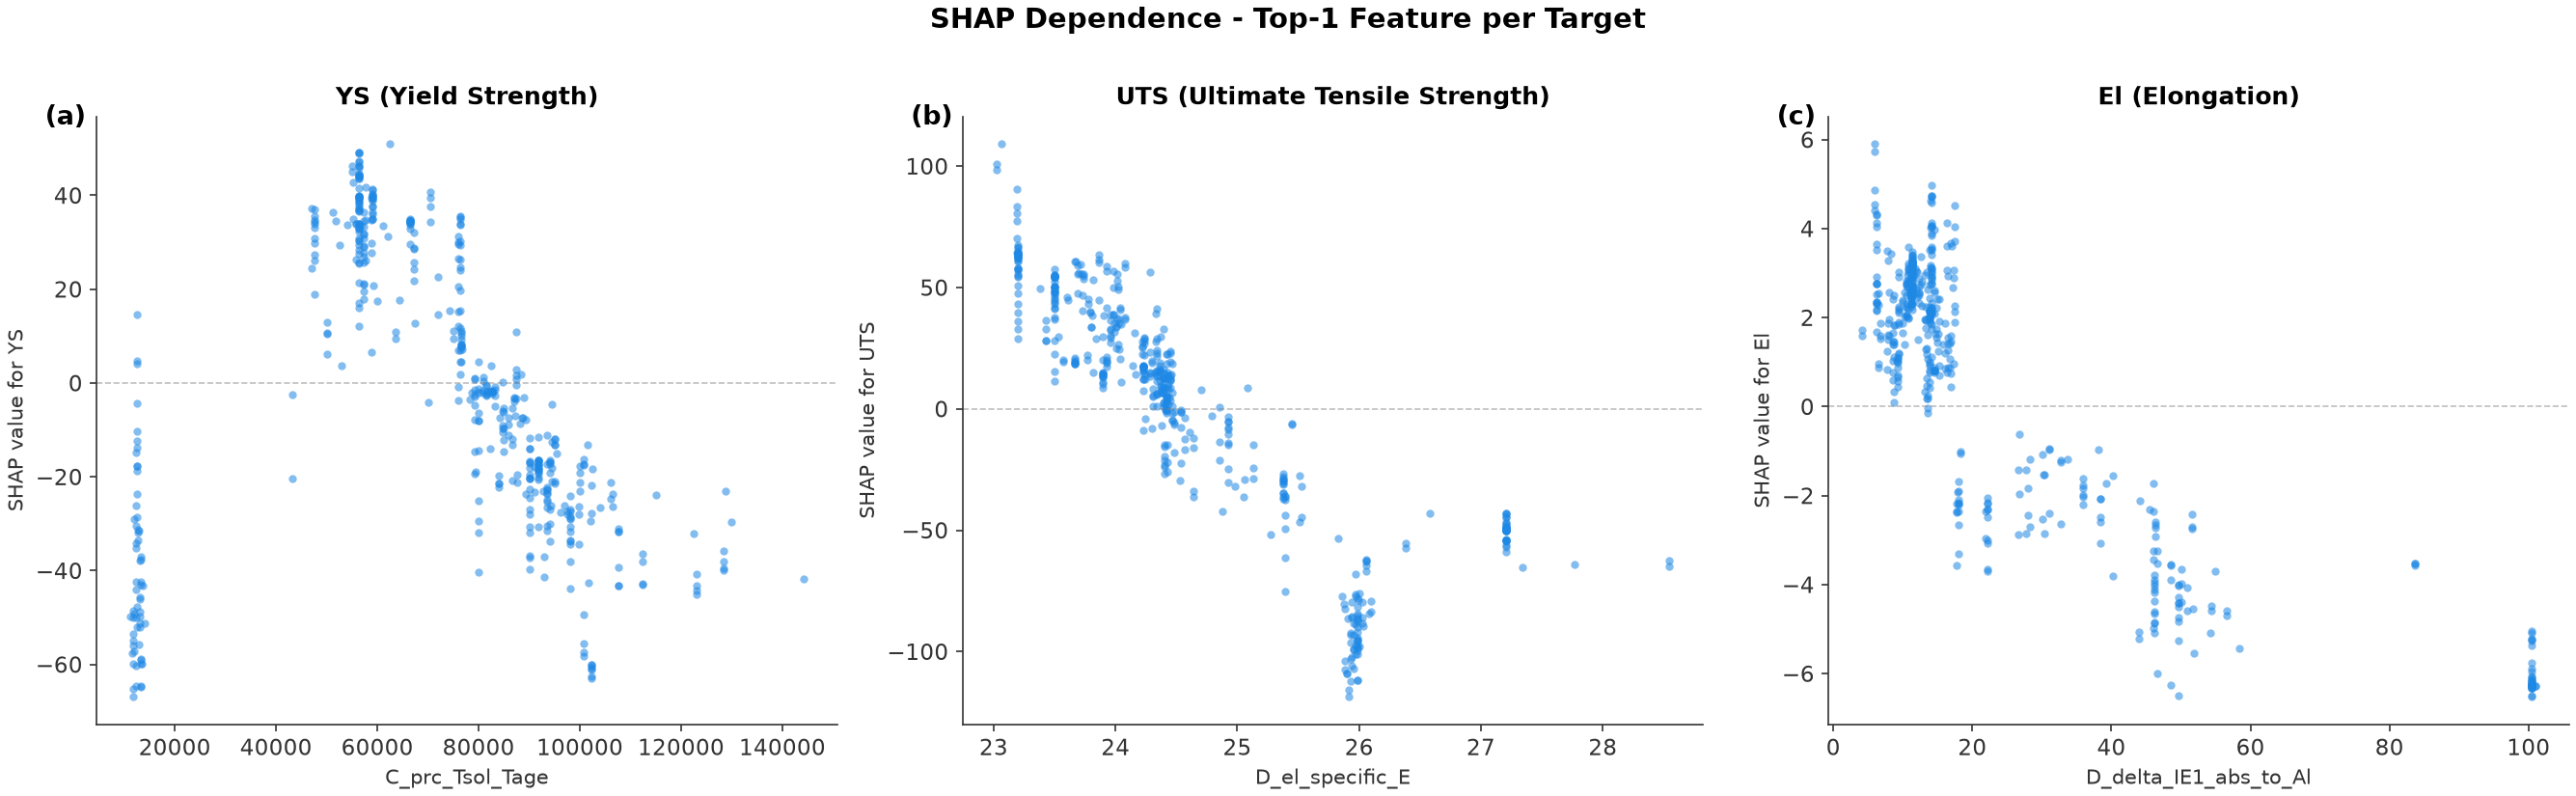

Dependence 1x3 figure saved.


In [24]:
# ══════════════════════════════════════════════════════════════
# 4a. DEPENDENCE 1x3 - Top-1 SHAP dependence per target
#     Shows SHAP(x) functional form (nonlinearities, thresholds, saturation)
#     that the polar bee-swarm cannot reveal.
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
panel_labels = ['(a)', '(b)', '(c)']

for ti, target_name in enumerate(TARGET_COLS):
    ax = axes[ti]
    if shap_results[target_name] is None:
        ax.text(0.5, 0.5, f'{target_name}: N/A', transform=ax.transAxes,
               ha='center', va='center')
        continue

    sr = shap_results[target_name]
    shap_vals = sr['values']
    X_raw = sr['X_raw']
    feats = sr['feat_names']
    mean_abs = np.abs(shap_vals).mean(axis=0)
    top_fi = int(np.argmax(mean_abs))

    shap.dependence_plot(
        top_fi, shap_vals, X_raw, feature_names=feats,
        interaction_index=None, show=False, ax=ax, alpha=0.55
    )
    ax.set_xlabel(feats[top_fi], fontsize=10)
    ax.set_ylabel(f'SHAP value for {target_name}', fontsize=10)
    ax.set_title(f'{target_name} ({TARGET_LABELS[target_name]})',
                 fontsize=12, fontweight='bold')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(-0.07, 1.02, panel_labels[ti], transform=ax.transAxes,
            fontsize=13, fontweight='bold', va='top')

fig.suptitle('SHAP Dependence - Top-1 Feature per Target',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'SHAP_dependence_1x3.pdf'),
            dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Dependence 1x3 figure saved.')


#### WATERFALL 1×3

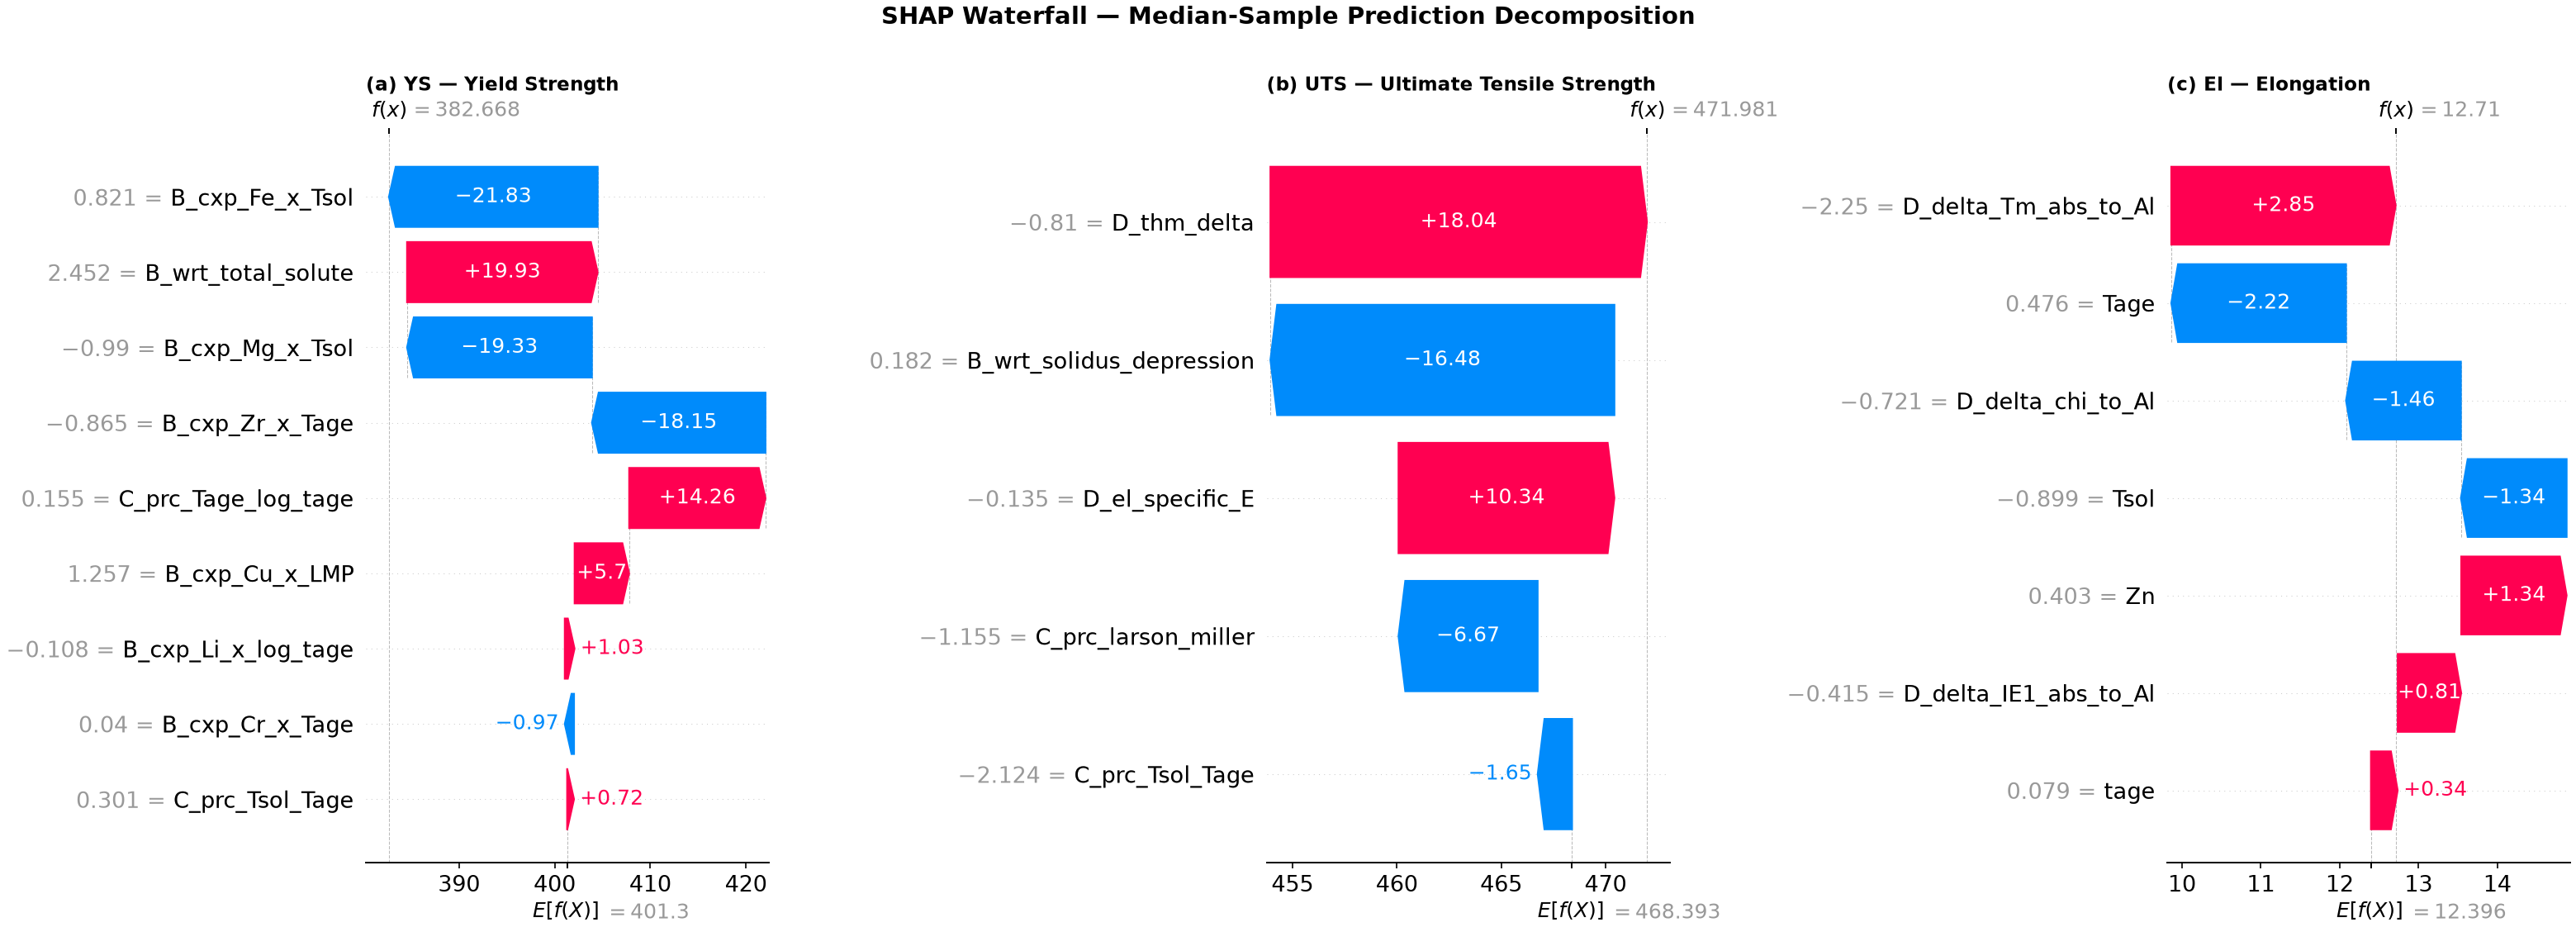

Waterfall 1x3 figure saved (SHAP official rendering).


In [30]:
# ══════════════════════════════════════════════════════════════
# 4b. WATERFALL 1×3 — SHAP official waterfall in subplots
#     shap.plots.waterfall uses plt.gcf()/plt.gca() internally
#     (no plt.figure() call), so we can redirect drawing into
#     our subplots via plt.sca(ax). We monkey-patch only
#     set_size_inches to prevent figure-wide resizing.
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(21, 7.5))
panel_labels = ['(a)', '(b)', '(c)']

# Save interactive state (shap.plots.waterfall calls plt.ioff() internally)
_was_interactive = plt.isinteractive()

for ti, target_name in enumerate(TARGET_COLS):
    ax = axes[ti]
    if shap_results[target_name] is None:
        ax.text(0.5, 0.5, f'{target_name}: N/A', transform=ax.transAxes,
               ha='center', va='center')
        ax.set_title(target_name)
        continue

    sr = shap_results[target_name]
    shap_vals = sr['values']
    X_scaled = sr['X_scaled']
    feats = sr['feat_names']
    explainer = sr['explainer']

    # Expected value
    if hasattr(explainer, 'expected_value'):
        ev = explainer.expected_value
        if isinstance(ev, np.ndarray):
            ev = float(ev[0]) if len(ev) == 1 else float(np.mean(ev))
        else:
            ev = float(ev)
    else:
        ev = 0.0

    # Median-prediction sample
    model = models[target_name]['model']
    y_pred = model.predict(X_scaled)
    median_idx = int(np.argsort(y_pred)[len(y_pred) // 2])

    # Build SHAP Explanation (what shap.plots.waterfall expects)
    exp = shap.Explanation(
        values=shap_vals[median_idx],
        base_values=ev,
        data=X_scaled[median_idx],
        feature_names=feats,
    )

    # ---- Redirect official waterfall into OUR subplot ----
    plt.sca(ax)  # make this axes current

    # Patch: prevent shap from resizing the ENTIRE figure
    _orig_set_size = fig.set_size_inches
    fig.set_size_inches = lambda *a, **kw: None

    # Draw SHAP official waterfall (uses plt.gca() → our ax)
    shap.plots.waterfall(exp, max_display=len(feats), show=False)

    # Restore figure resize
    fig.set_size_inches = _orig_set_size

    # ---- Customize title with (a)/(b)/(c) ----
    existing_title = ax.get_title()
    if existing_title:
        ax.set_title(f'{panel_labels[ti]} {existing_title}',
                    fontsize=11, fontweight='bold', loc='left')
    else:
        ax.set_title(f'{panel_labels[ti]} {target_name} — {TARGET_LABELS[target_name]}',
                    fontsize=11, fontweight='bold', loc='left')

# Restore interactive mode if originally on
if _was_interactive:
    plt.ion()

fig.suptitle('SHAP Waterfall — Median-Sample Prediction Decomposition',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'SHAP_waterfall_1x3.pdf'),
            dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Waterfall 1x3 figure saved (SHAP official rendering).')


### Polar SHAP Bee-Swarm  1×3 

Consolidated publication figure: inner rose bars = mean |SHAP| ranking,
outer dots = individual SHAP values colored by feature value (coolwarm).
Combines bee-swarm distribution + bar importance + feature-value dependence
in a single polar layout. 

In [12]:
# ══════════════════════════════════════════════════════════════
# 4d-2. Polar bee-swarm helper functions (adapted for N05 data)
# ══════════════════════════════════════════════════════════════
from matplotlib.transforms import offset_copy
from matplotlib.patches import Patch

def simple_beeswarm_n05(y, nbins=None, width=1.0):
    """Bee-swarm dot layout: returns x-offsets for each data point."""
    y = np.asarray(y)
    if nbins is None:
        nbins = max(len(y) // 6, 1)
    nbins = int(nbins)
    x = np.zeros(len(y))
    ylo, yhi = np.min(y), np.max(y)
    if ylo == yhi:
        return x
    dy = (yhi - ylo) / nbins
    ybins = np.linspace(ylo + dy, yhi - dy, nbins - 1)
    i = np.arange(len(y))
    ibs, ybs = [None] * nbins, [None] * nbins
    nmax = 0
    for j, ybin in enumerate(ybins):
        f = y <= ybin
        ibs[j], ybs[j] = i[f], y[f]
        nmax = max(nmax, len(ibs[j]))
        f = ~f
        i, y = i[f], y[f]
    ibs[-1], ybs[-1] = i, y
    nmax = max(nmax, len(ibs[-1]))
    dx = width / (nmax // 2 + 1)
    for ii, yy in zip(ibs, ybs):
        if ii is None or len(ii) <= 1:
            continue
        j = len(ii) % 2
        ii = ii[np.argsort(yy)]
        a = ii[j::2]
        b = ii[j + 1::2]
        x[a] = (0.5 + j / 3 + np.arange(len(a))) * dx
        x[b] = (0.5 + j / 3 + np.arange(len(b))) * -dx
    return x


def _angle_text_props(angle):
    """Return horizontal alignment for a given polar angle."""
    deg = (np.degrees(angle) + 360) % 360
    if 15 <= deg <= 165:
        return 'left'
    if 195 <= deg <= 345:
        return 'right'
    return 'center'


def plot_one_polar_n05(ax, sv, X_raw, feat_names, rose_color, panel_label, target_label):
    """
    Draw a single polar SHAP bee-swarm panel.

    Parameters
    ----------
    ax : matplotlib Axes (polar projection)
    sv : (N, F) SHAP values
    X_raw : (N, F) raw (unscaled) feature values for color-coding
    feat_names : list of F feature names
    rose_color : bar color (hex)
    panel_label : '(a)', '(b)', '(c)'
    target_label : 'YS', 'UTS', 'El'
    """
    n_feat = sv.shape[1]
    cmap = plt.get_cmap('coolwarm')
    np.random.seed(42)

    # Rank features by mean|SHAP|
    mean_abs = np.abs(sv).mean(axis=0)
    order = np.argsort(mean_abs)[::-1]
    sv_ord = sv[:, order]
    X_ord = X_raw[:, order]
    cols_ord = [feat_names[i] for i in order]
    mean_ord = mean_abs[order]

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    angles = np.linspace(0, 2 * np.pi, n_feat, endpoint=False)
    sector = 2 * np.pi / n_feat
    swarm_width = sector * 0.16

    # Radial scaling
    all_sv = sv_ord.flatten()
    shap_min = float(np.min(all_sv))
    shap_max = float(np.max(all_sv))
    max_abs = max(float(np.max(np.abs(all_sv))), 1e-12)

    inner_bar_max = max_abs * 0.9
    white_gap = max_abs * 0.1
    shift = abs(shap_min) + inner_bar_max + white_gap

    max_mean = max(float(np.max(mean_ord)), 1e-12)
    mean_bar = (mean_ord / max_mean) * inner_bar_max

    zero_r = shift
    r_min = shap_min + shift
    r_max = shap_max + shift
    outer_r = r_max + max_abs * 0.10

    # --- Styling parameters ---
    title_fs, feature_fs = 12, 10.5
    legend_fs, mean_tick_fs, shap_tick_fs = 9, 6.8, 6.8
    title_color = '#2E2E2E'
    feature_color = '#4A4A4A'
    number_color = '#3A3A3A'
    guide_color = '#C8C8C8'
    outer_color = '#9A9A9A'
    axis_line_color = '#8A8A8A'
    tick_line_color = '#6F6F6F'
    shap_axis_color = '#C2C2C2'

    # --- Inner bar: mean |SHAP| ---
    bar_bottom = 0.0
    ax.bar(angles, mean_bar, width=sector * 0.68, align='center',
           bottom=bar_bottom, color=rose_color, alpha=0.7,
           edgecolor='none', zorder=3)

    # --- Mean-bar axis line & ticks ---
    angle_top = 0.0
    ax.plot([angle_top, angle_top], [bar_bottom, bar_bottom + inner_bar_max * 1.03],
            color=axis_line_color, lw=0.9, zorder=4)
    mean_tick_vals = np.linspace(0, max_mean, 4)
    for v in mean_tick_vals:
        r = bar_bottom + (v / (max_mean + 1e-12)) * inner_bar_max
        ax.plot([angle_top - 0.024, angle_top + 0.024], [r, r],
                color=tick_line_color, lw=1.0, zorder=5)
        trans = offset_copy(ax.transData, fig=ax.figure, x=-7, y=0, units='points')
        ax.text(angle_top, r, f'{v:.1f}', transform=trans,
                ha='right', va='center', fontsize=mean_tick_fs,
                color=number_color,
                bbox=dict(boxstyle='square,pad=0.05',
                          facecolor=(1, 1, 1, 0.75), edgecolor='none'),
                zorder=6)

    # --- Bee-swarm scatter dots ---
    for fi in range(n_feat):
        sv_col = sv_ord[:, fi]
        x_col = X_ord[:, fi]
        x_off = simple_beeswarm_n05(sv_col, nbins=120, width=swarm_width)
        radius = sv_col + shift
        vmin, vmax = np.percentile(x_col, [5, 95])
        if np.isclose(vmin, vmax):
            vmin, vmax = np.min(x_col), np.max(x_col)
        norm = np.clip((x_col - vmin) / (vmax - vmin + 1e-12), 0, 1)
        colors = cmap(norm)
        ax.scatter(angles[fi] + x_off, radius, c=colors, s=8,
                   alpha=0.55, linewidths=0, rasterized=True, zorder=4)

    # --- Guide circles ---
    theta = np.linspace(0, 2 * np.pi, 720)
    ax.plot(theta, np.full_like(theta, zero_r), color=guide_color, lw=0.7, zorder=1)
    ax.plot(theta, np.full_like(theta, outer_r), color=outer_color, lw=0.9, zorder=1)
    ax.plot(theta, np.full_like(theta, inner_bar_max), color='#D7D7D7', lw=0.6, zorder=1)

    # --- Outer tick marks ---
    for ang in angles:
        ax.plot([ang, ang], [outer_r - outer_r * 0.018, outer_r],
                color=outer_color, lw=0.7, zorder=1)

    # --- SHAP value axes & ticks (right & left sides) ---
    tick_vals = np.array([shap_min, shap_min / 2, 0.0, shap_max / 2, shap_max])
    tick_vals = np.unique(np.round(tick_vals, 1))
    tick_angles = [np.pi / 2, 3 * np.pi / 2]
    for angle_c in tick_angles:
        ax.plot([angle_c, angle_c], [r_min, r_max], color=shap_axis_color, lw=0.8, zorder=1)
        for val in tick_vals:
            r = val + shift
            ax.plot([angle_c - 0.016, angle_c + 0.016], [r, r],
                    color=tick_line_color, lw=0.9, zorder=2)
            trans = offset_copy(ax.transData, fig=ax.figure, x=0, y=-7, units='points')
            ax.text(angle_c, r, f'{val:.1f}', fontsize=shap_tick_fs,
                    color=number_color, ha='center', va='top',
                    transform=trans, zorder=5)

    # --- Feature name labels ---
    label_r = outer_r + max_abs * 0.22
    for ang, name in zip(angles, cols_ord):
        ha = _angle_text_props(ang)
        ax.text(ang, label_r, name, fontsize=feature_fs, fontweight='normal',
                color=feature_color, ha=ha, va='center', rotation=0,
                clip_on=False, zorder=6)

    # --- Titles ---
    ax.text(-0.12, 1.15, panel_label, transform=ax.transAxes,
            ha='left', va='top', fontsize=14, fontweight='bold', clip_on=False)
    ax.text(0.5, 1.09, f'Feature impact for {target_label}',
            transform=ax.transAxes, ha='center', va='center',
            fontsize=title_fs, fontweight='normal', color=title_color)

    # --- Legend ---
    patch = Patch(facecolor=rose_color, edgecolor='none', label='Mean (|SHAP value|)')
    ax.legend(handles=[patch], loc='lower center',
              bbox_to_anchor=(0.5, -0.16), frameon=False, fontsize=legend_fs,
              handlelength=1.4, borderaxespad=0.0)

    ax.set_ylim(0, label_r + max_abs * 0.08)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.spines['polar'].set_visible(False)

print('✓ Polar bee-swarm helper functions defined.')

✓ Polar bee-swarm helper functions defined.


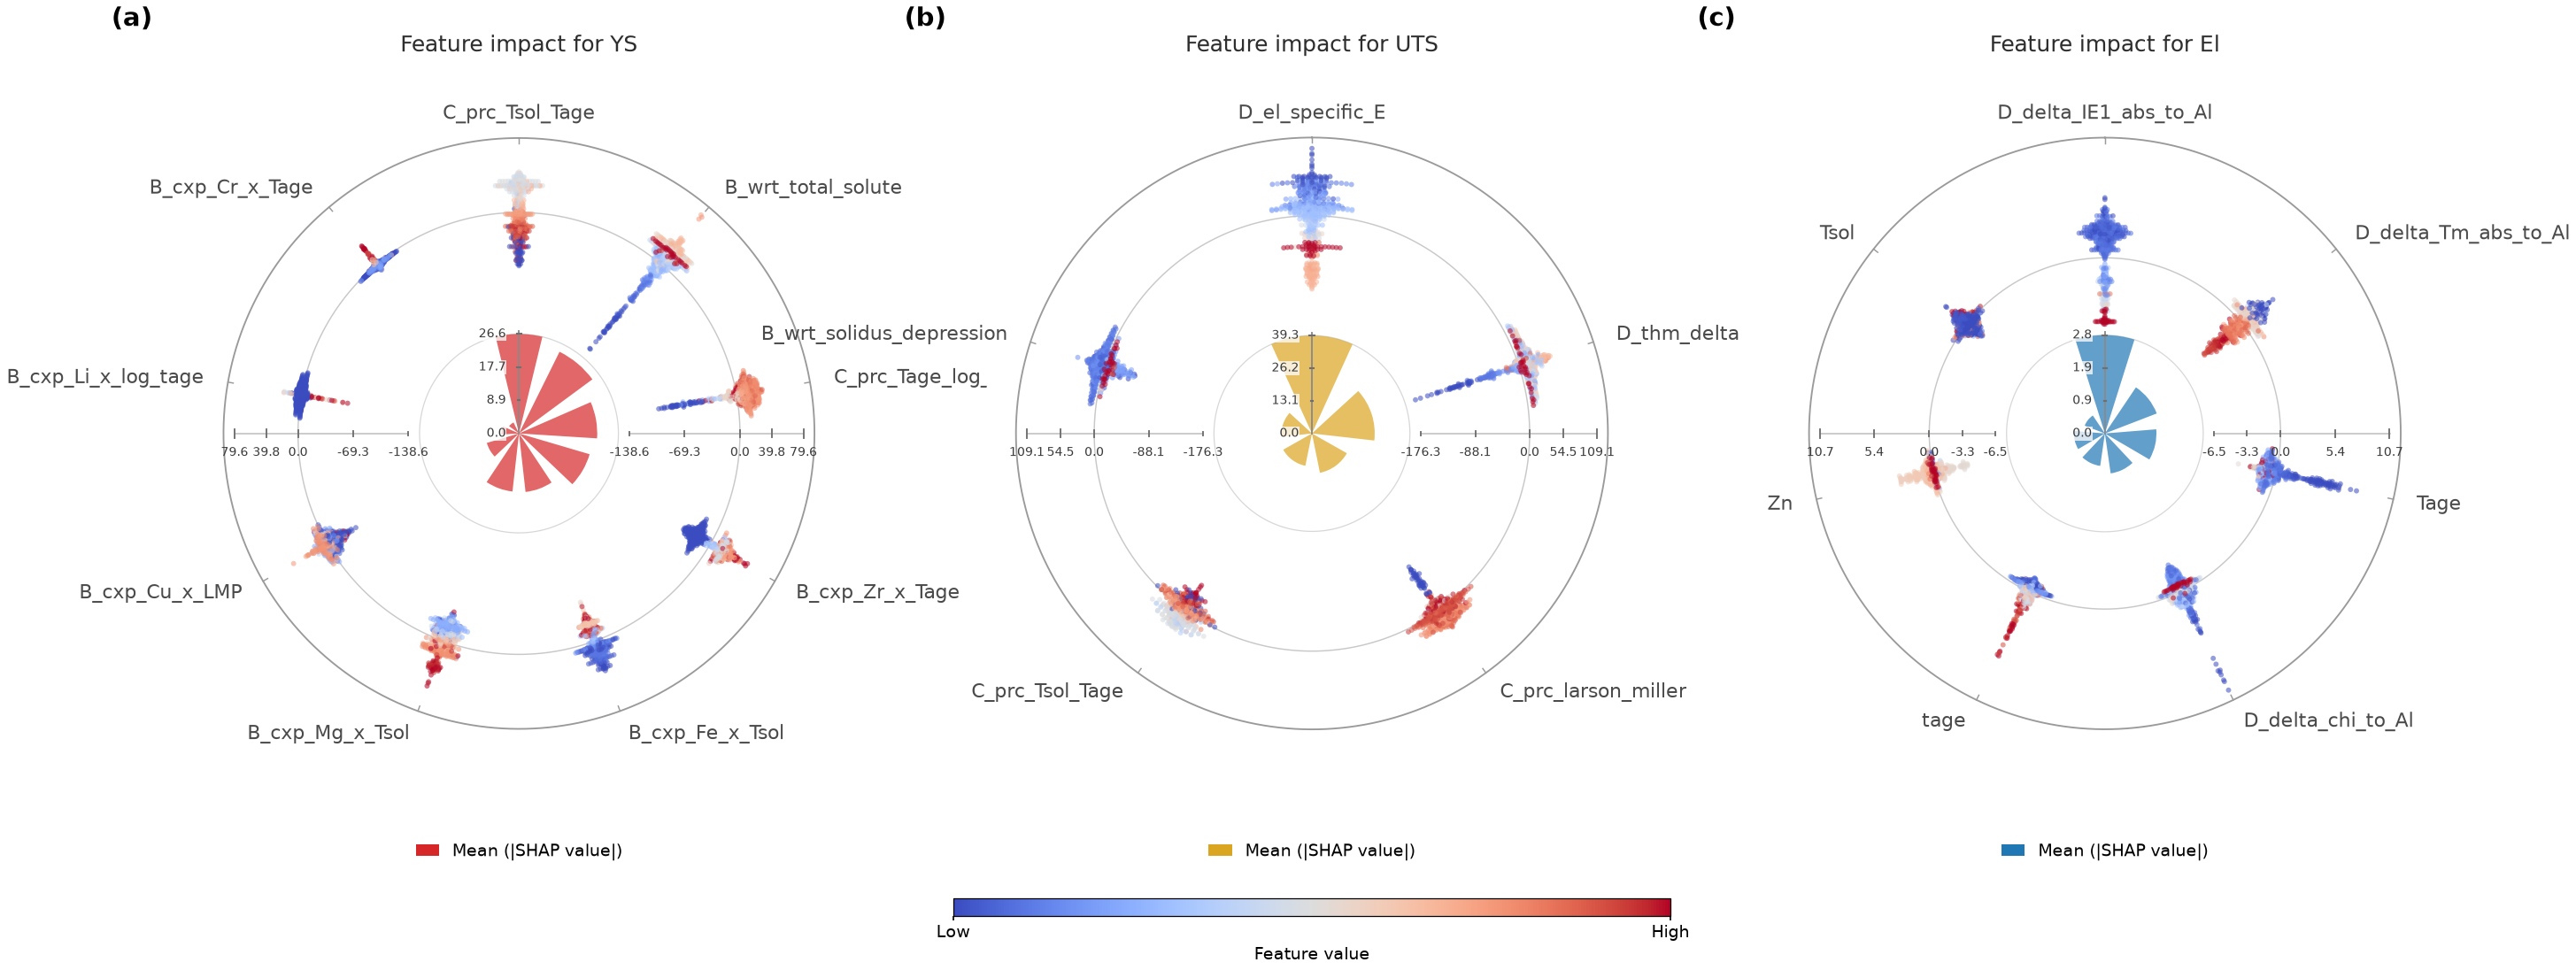

✓ Polar SHAP bee-swarm 1×3 figure saved.


In [13]:
# ══════════════════════════════════════════════════════════════
# 4d-3. 1×3 Polar SHAP Bee-Swarm Figure (极坐标蜂巢图)
# ══════════════════════════════════════════════════════════════
TARGET_CONFIG = [
    ('YS',  TARGET_COLORS['YS'],  '(a)'),
    ('UTS', TARGET_COLORS['UTS'], '(b)'),
    ('El',  TARGET_COLORS['El'],  '(c)'),
]

fig = plt.figure(figsize=(18, 7.5))

for idx, (target, color, panel) in enumerate(TARGET_CONFIG):
    ax = fig.add_subplot(1, 3, idx + 1, projection='polar')
    sr = shap_results[target]
    if sr is None:
        continue
    plot_one_polar_n05(
        ax,
        sr['values'],
        sr['X_raw'],
        sr['feat_names'],
        rose_color=color,
        panel_label=panel,
        target_label=target,
    )

# Shared colorbar for feature value
cbar_ax = fig.add_axes([0.35, 0.065, 0.30, 0.018])
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Low', 'High'])
cbar.ax.tick_params(labelsize=9, length=2.5, pad=2)
cbar.outline.set_linewidth(0.6)
cbar.set_label('Feature value', fontsize=9, labelpad=3)

fig.subplots_adjust(left=0.03, right=0.97, top=0.88, bottom=0.22, wspace=0.20)

plt.savefig(os.path.join(FIGURE_DIR, 'SHAP_polar_beeswarm_1x3.pdf'),
            dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('✓ Polar SHAP bee-swarm 1×3 figure saved.')

## 5. Cross-Target SHAP Comparison

In [14]:
# 5a. Feature overlap printed to console only (no separate figure).
print('Cross-target feature overlap (see combined figure for visualization):')
all_feats_sets = {t: set(models[t]['features']) for t in TARGET_COLS}
for t in TARGET_COLS:
    others = set()
    for t2 in TARGET_COLS:
        if t2 != t: others |= all_feats_sets[t2]
    unique = all_feats_sets[t] - others
    print(f'  {t}: {len(all_feats_sets[t])} total, {len(unique)} unique')


Cross-target feature overlap (see combined figure for visualization):
  YS: 9 total, 8 unique
  UTS: 5 total, 4 unique
  El: 7 total, 7 unique


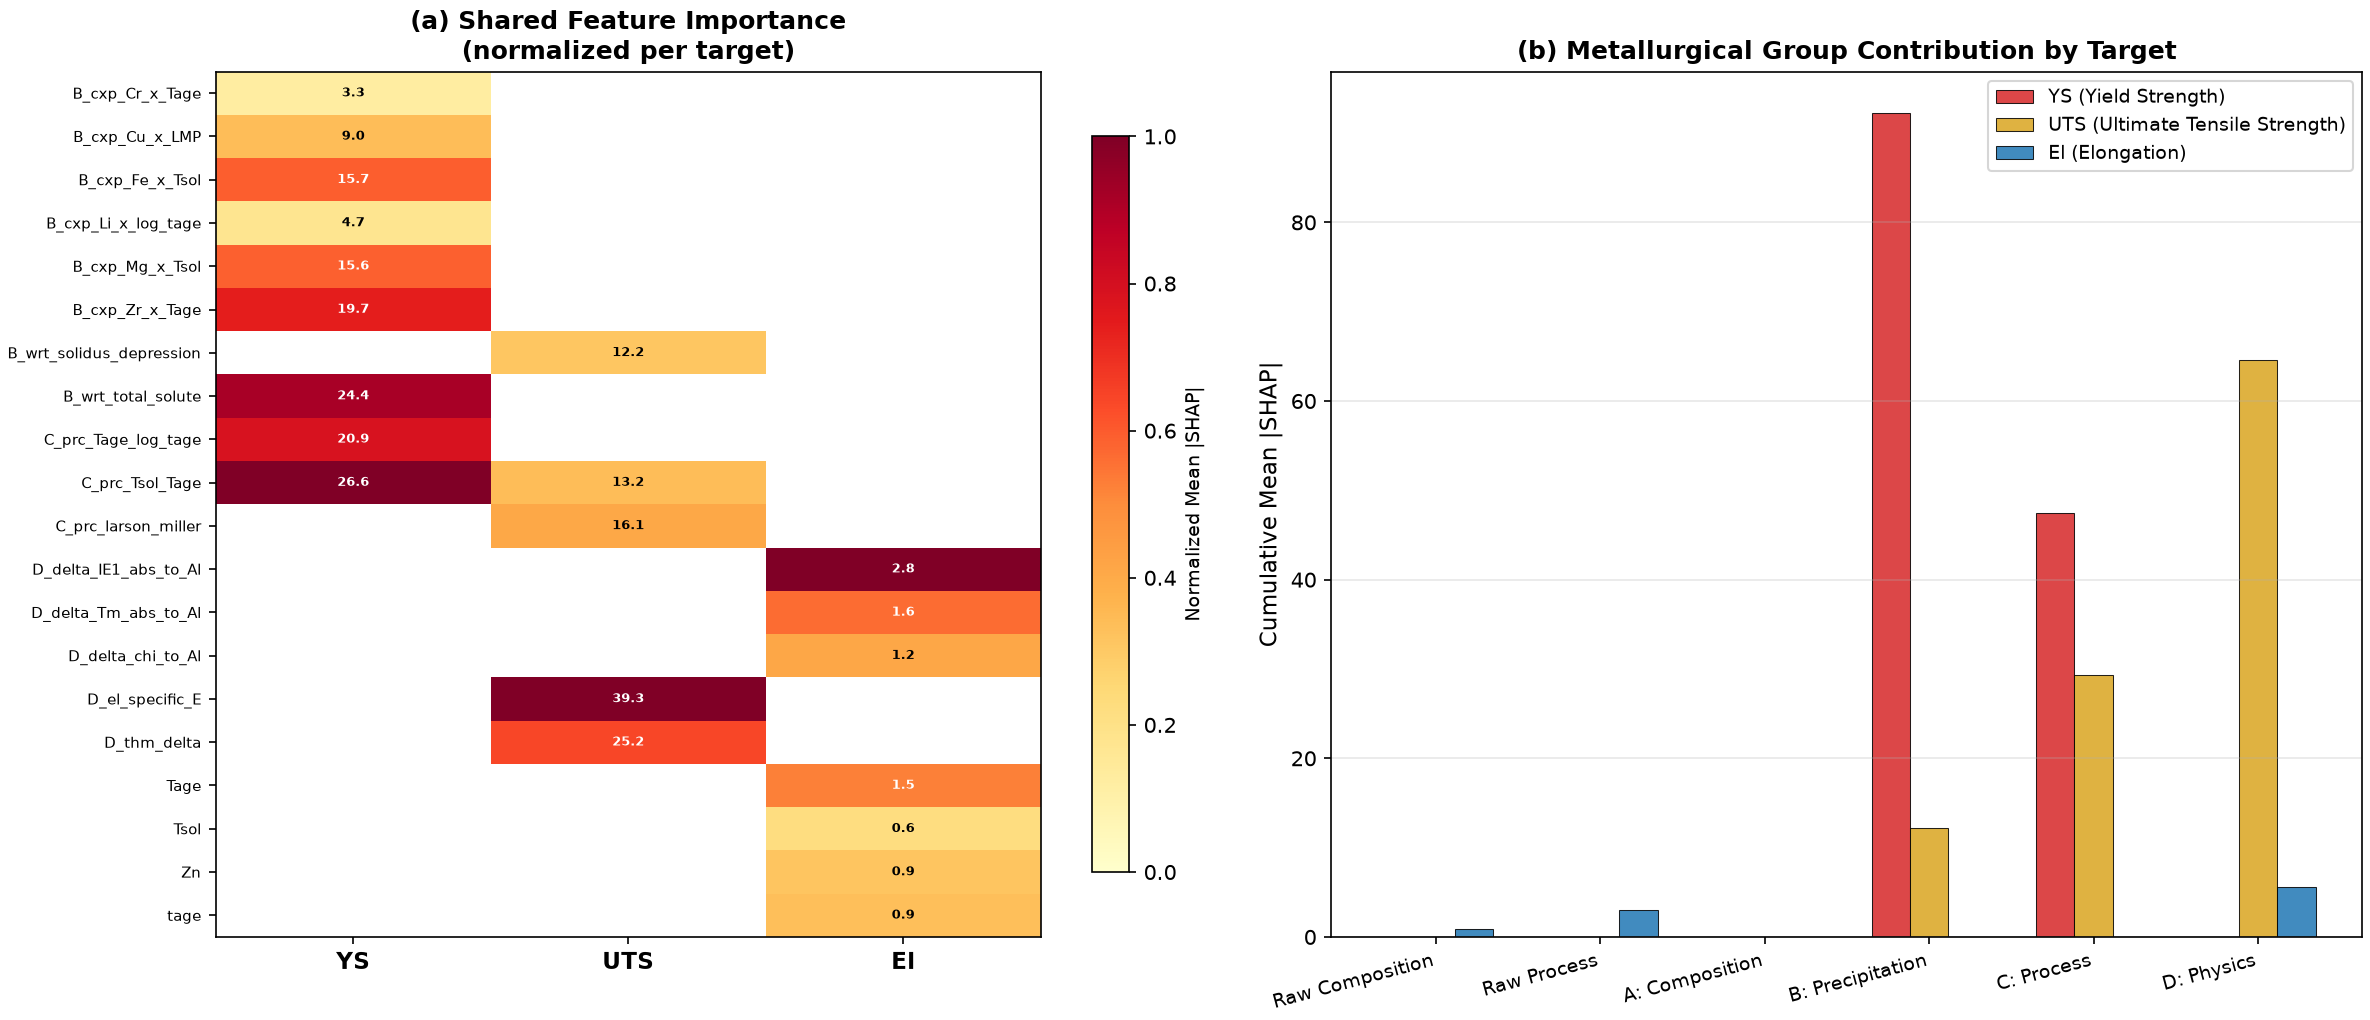

Cross-target combined figure saved.


In [15]:
# ══════════════════════════════════════════════════════════════
# 5. CROSS-TARGET COMBINED - (a) Shared-feature heatmap + (b) Group comparison
#    Reveals feature sharing patterns & metallurgical group dominance across targets.
# ══════════════════════════════════════════════════════════════
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 7))

# --- Left panel: Shared-feature heatmap ---
all_shared_feats = set()
for t in TARGET_COLS:
    if shap_results[t] is not None:
        all_shared_feats.update(shap_results[t]['feat_names'])
all_shared_feats = sorted(all_shared_feats)

shap_matrix = np.full((len(all_shared_feats), len(TARGET_COLS)), np.nan)
for ti, t in enumerate(TARGET_COLS):
    if shap_results[t] is None:
        continue
    sr = shap_results[t]
    mean_abs = np.abs(sr['values']).mean(axis=0)
    f2i = {f: i for i, f in enumerate(sr['feat_names'])}
    for fi, f in enumerate(all_shared_feats):
        if f in f2i:
            shap_matrix[fi, ti] = mean_abs[f2i[f]]

shap_norm = shap_matrix.copy()
for ti in range(len(TARGET_COLS)):
    col_max = np.nanmax(shap_norm[:, ti])
    if col_max > 0:
        shap_norm[:, ti] /= col_max

has_val = ~np.all(np.isnan(shap_norm), axis=1)
plot_feats = [all_shared_feats[i] for i in range(len(all_shared_feats)) if has_val[i]]
plot_mat = shap_norm[has_val, :]
plot_raw = shap_matrix[has_val, :]

if len(plot_feats) > 0:
    im = ax_left.imshow(plot_mat, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    ax_left.set_xticks(range(len(TARGET_COLS)))
    ax_left.set_xticklabels(TARGET_COLS, fontsize=11, fontweight='bold')
    ax_left.set_yticks(range(len(plot_feats)))
    ax_left.set_yticklabels(plot_feats, fontsize=7)
    ax_left.set_title('(a) Shared Feature Importance\n(normalized per target)',
                       fontsize=12, fontweight='bold')
    for i in range(len(plot_feats)):
        for j in range(len(TARGET_COLS)):
            val = plot_raw[i, j]
            if not np.isnan(val) and val > 0:
                ax_left.text(j, i, f'{val:.1f}', ha='center', va='center',
                           fontsize=6, fontweight='bold',
                           color='white' if plot_mat[i, j] > 0.5 else 'black')
    cbar = plt.colorbar(im, ax=ax_left, shrink=0.85)
    cbar.set_label('Normalized Mean |SHAP|', fontsize=9)

# --- Right panel: Group contribution comparison ---
group_target_shap = {g: [] for g in GROUP_ORDER}
for t in TARGET_COLS:
    if shap_results[t] is None:
        for g in GROUP_ORDER:
            group_target_shap[g].append(0)
        continue
    sr = shap_results[t]
    mean_abs = np.abs(sr['values']).mean(axis=0)
    groups = get_feature_groups(sr['feat_names'])
    gsum = {}
    for i, g in enumerate(groups):
        gsum[g] = gsum.get(g, 0) + mean_abs[i]
    for g in GROUP_ORDER:
        group_target_shap[g].append(gsum.get(g, 0))

x = np.arange(len(GROUP_ORDER))
n_targets = len(TARGET_COLS)
width = 0.7 / n_targets
for ti, t in enumerate(TARGET_COLS):
    offset = (ti - n_targets/2 + 0.5) * width
    vals = [group_target_shap[g][ti] for g in GROUP_ORDER]
    ax_right.bar(x + offset, vals, width, label=f'{t} ({TARGET_LABELS[t]})',
                 color=TARGET_COLORS[t], edgecolor='k', linewidth=0.5, alpha=0.85)

ax_right.set_xticks(x)
ax_right.set_xticklabels(GROUP_ORDER, rotation=15, ha='right', fontsize=9)
ax_right.set_ylabel('Cumulative Mean |SHAP|', fontsize=11)
ax_right.set_title('(b) Metallurgical Group Contribution by Target',
                    fontsize=12, fontweight='bold')
ax_right.legend(fontsize=9)
ax_right.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'SHAP_cross_target_combined.pdf'),
            dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Cross-target combined figure saved.')


## 6. SHAP vs Built-in Feature Importance Consistency


YS: SHAP vs feature_importances_ — Spearman ρ=0.9500 (p=8.76e-05), Pearson r=0.9366
UTS: SHAP vs feature_importances_ — Spearman ρ=0.7000 (p=1.88e-01), Pearson r=0.9257
El: SHAP vs feature_importances_ — Spearman ρ=0.7143 (p=7.13e-02), Pearson r=0.6781


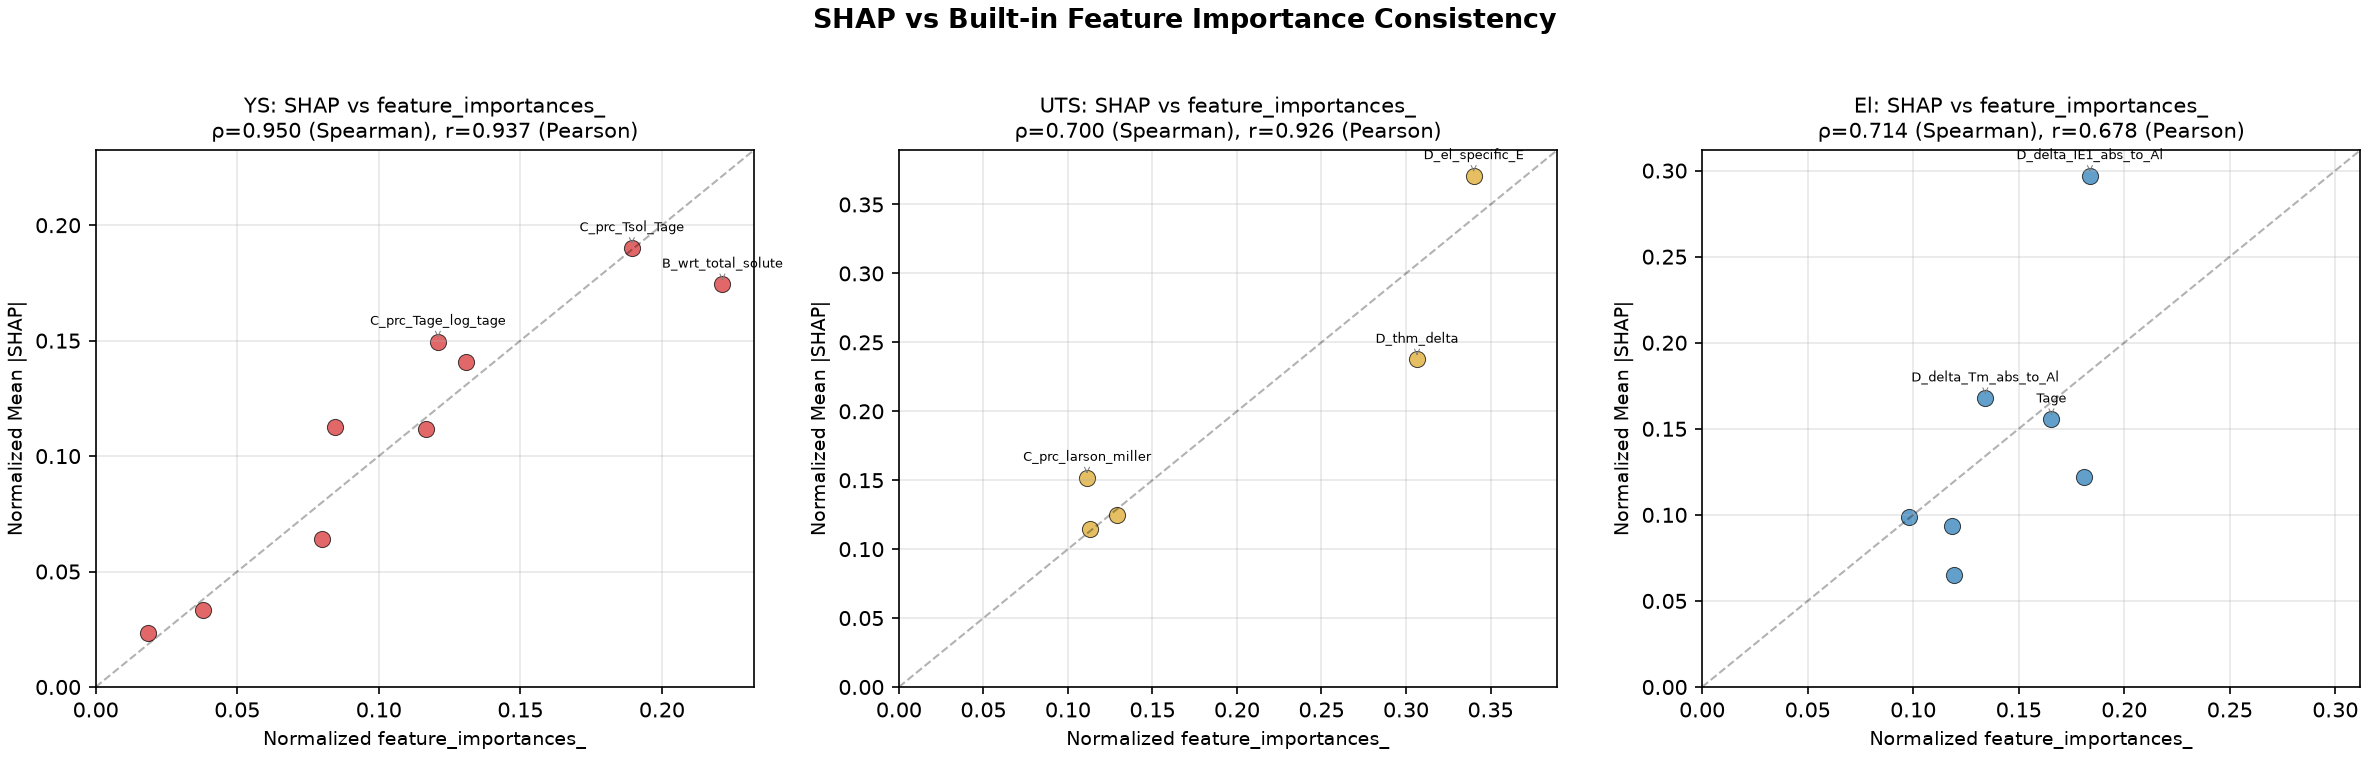


✓ SHAP vs built-in importance comparison saved.


In [16]:
# ══════════════════════════════════════════════════════════════
# 7. Compare SHAP ranking with model.feature_importances_
#     (for tree models) and coefficients (for linear models)
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(TARGET_COLS), figsize=(16, 5))
if len(TARGET_COLS) == 1:
    axes = [axes]

for ti, target_name in enumerate(TARGET_COLS):
    ax = axes[ti]
    
    if shap_results[target_name] is None:
        ax.text(0.5, 0.5, f'{target_name}: SHAP failed', transform=ax.transAxes,
               ha='center', va='center')
        ax.set_title(target_name)
        continue
    
    sr = shap_results[target_name]
    mean_abs_shap = np.abs(sr['values']).mean(axis=0)
    feats = sr['feat_names']
    
    model = models[target_name]['model']
    
    # Get built-in importance (tree models) or |coefficients| (linear models)
    if hasattr(model, 'feature_importances_'):
        builtin_imp = model.feature_importances_
        imp_label = 'feature_importances_'
    elif hasattr(model, 'coef_'):
        builtin_imp = np.abs(model.coef_).flatten()
        imp_label = '|coefficients|'
    else:
        print(f'{target_name}: No feature_importances_ or coef_ — skipping consistency check.')
        ax.text(0.5, 0.5, f'{target_name}: No built-in importance', 
               transform=ax.transAxes, ha='center', va='center')
        ax.set_title(target_name)
        continue
    
    # Normalize both to [0, 1] for comparison
    shap_norm = mean_abs_shap / mean_abs_shap.sum()
    builtin_norm = builtin_imp / builtin_imp.sum()
    
    # Scatter: SHAP vs built-in
    ax.scatter(builtin_norm, shap_norm, c=TARGET_COLORS[target_name], 
              alpha=0.7, edgecolors='k', linewidth=0.5, s=60)
    
    # Annotate top features
    top_n = min(3, len(feats))
    top_idx = np.argsort(mean_abs_shap)[-top_n:]
    for idx in top_idx:
        ax.annotate(feats[idx][:25], (builtin_norm[idx], shap_norm[idx]),
                   fontsize=6, ha='center',
                   xytext=(0, 8), textcoords='offset points',
                   arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))
    
    # Diagonal line
    lims = [0, max(builtin_norm.max(), shap_norm.max()) * 1.05]
    ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    # Spearman rank correlation
    rho, pval = spearmanr(mean_abs_shap, builtin_imp)
    r_pearson, _ = pearsonr(mean_abs_shap, builtin_imp)
    
    ax.set_xlabel(f'Normalized {imp_label}', fontsize=9)
    ax.set_ylabel('Normalized Mean |SHAP|', fontsize=9)
    ax.set_title(f'{target_name}: SHAP vs {imp_label}\n'
                f'ρ={rho:.3f} (Spearman), r={r_pearson:.3f} (Pearson)',
                fontsize=10)
    ax.grid(alpha=0.3)
    
    print(f'{target_name}: SHAP vs {imp_label} — '
          f'Spearman ρ={rho:.4f} (p={pval:.2e}), Pearson r={r_pearson:.4f}')

plt.suptitle('SHAP vs Built-in Feature Importance Consistency', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'SHAP_vs_builtin_importance.pdf'), 
            dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('\n✓ SHAP vs built-in importance comparison saved.')

验证：** 树模型原生特征重要度（基于节点分裂增益）与SHAP 全局特征重要度（平均绝对 SHAP 值）** 的一致性  

## 7. SHAP Statistical Summary (Text Output)

Per-feature SHAP statistics printed to console and exported to .


In [17]:
# ══════════════════════════════════════════════════════════════
# 8. SHAP value statistics & distribution
# ══════════════════════════════════════════════════════════════
print(f'\n{"="*70}')
print(' SHAP Value Statistical Summary')
print(f'{"="*70}')

summary_data = []
for target_name in TARGET_COLS:
    if shap_results[target_name] is None:
        continue
    sr = shap_results[target_name]
    shap_vals = sr['values']
    feats = sr['feat_names']
    mean_abs = np.abs(shap_vals).mean(axis=0)
    rank_order = np.argsort(mean_abs)[::-1]
    
    print(f'\n  {target_name} ({TARGET_LABELS[target_name]}):')
    print(f'    SHAP range: [{shap_vals.min():.3f}, {shap_vals.max():.3f}]')
    print(f'    Mean |SHAP|: {mean_abs.mean():.4f}')
    print(f'    Total |SHAP| sum: {mean_abs.sum():.4f}')
    print(f'    Top-1 feature accounts for: {mean_abs[rank_order[0]]/mean_abs.sum()*100:.1f}% of total |SHAP|')
    print(f'    Top-3 features account for: {mean_abs[rank_order[:3]].sum()/mean_abs.sum()*100:.1f}% of total |SHAP|')
    
    # Per-feature stats
    for rank, fi in enumerate(rank_order):
        shap_col = shap_vals[:, fi]
        summary_data.append({
            'Target': target_name,
            'Rank': rank + 1,
            'Feature': feats[fi],
            'Group': get_feature_group(feats[fi]),
            'Mean|SHAP|': mean_abs[fi],
            'SHAP_std': shap_col.std(),
            'SHAP_min': shap_col.min(),
            'SHAP_max': shap_col.max(),
            'Direction': 'Positive' if shap_col.mean() > 0 else 'Negative',
        })
        if rank < 3:
            print(f'      #{rank+1}: {feats[fi]:40s} '
                  f'|SHAP|={mean_abs[fi]:.3f}±{shap_col.std():.3f} '
                  f'[{shap_col.min():.3f}, {shap_col.max():.3f}] '
                  f'({get_feature_group(feats[fi])})')

# Create summary dataframe
df_summary = pd.DataFrame(summary_data)
print(f'\nSummary table: {len(df_summary)} rows × {len(df_summary.columns)} columns')


 SHAP Value Statistical Summary

  YS (Yield Strength):
    SHAP range: [-138.631, 79.622]
    Mean |SHAP|: 15.5288
    Total |SHAP| sum: 139.7594
    Top-1 feature accounts for: 19.0% of total |SHAP|
    Top-3 features account for: 51.4% of total |SHAP|
      #1: C_prc_Tsol_Tage                          |SHAP|=26.575±30.656 [-66.871, 50.940] (C: Process)
      #2: B_wrt_total_solute                       |SHAP|=24.373±34.862 [-138.631, 79.622] (B: Precipitation)
      #3: C_prc_Tage_log_tage                      |SHAP|=20.909±28.608 [-99.206, 32.653] (C: Process)

  UTS (Ultimate Tensile Strength):
    SHAP range: [-176.297, 109.099]
    Mean |SHAP|: 21.2198
    Total |SHAP| sum: 106.0989
    Top-1 feature accounts for: 37.1% of total |SHAP|
    Top-3 features account for: 76.0% of total |SHAP|
      #1: D_el_specific_E                          |SHAP|=39.340±48.454 [-118.582, 109.099] (D: Physics)
      #2: D_thm_delta                              |SHAP|=25.208±38.338 [-176.297, 52.9

## 8. Metallurgical Interpretation Summary

Map SHAP importance to underlying physical mechanisms for each target property.


In [18]:
# ══════════════════════════════════════════════════════════════
# 9. Metallurgical mechanism interpretation
# ══════════════════════════════════════════════════════════════
# Map feature name patterns to physical strengthening mechanisms
MECHANISM_MAP = {
    # B_cxp_* features: Composition × Process interactions → precipitation kinetics
    'cxp_Cu': 'Cu precipitation (θ/Al₂Cu)',
    'cxp_Mg': 'Mg-related precipitation',
    'cxp_Zn': 'Zn-related precipitation (η/MgZn₂)',
    'cxp_Zr': 'Zr dispersoid (Al₃Zr)',
    'cxp_Cr': 'Cr dispersoid (Al₇Cr)',
    'cxp_Fe': 'Fe intermetallic effect',
    'cxp_Li': 'Li precipitation (δ/Al₃Li)',
    # B_wrt_* features: Wrought-specific metallurgy
    'wrt_total_solute': 'Solid solution strengthening',
    'wrt_solidus_depression': 'Incipient melting / homogenization',
    # C_prc_* features: Process parameters
    'larson_miller': 'Larson-Miller (thermal exposure)',
    'Tage_log_tage': 'Aging kinetics (T×log t)',
    'Tsol_Tage': 'Solution-aging temperature gap',
    # D_* features: Physics-based
    'thm_delta': 'Thermodynamic δ (phase stability)',
    'el_specific_E': 'Specific elastic modulus',
    'delta_Tm': 'Melting point deviation → solute effect',
    'delta_chi': 'Electronegativity difference → bonding',
    'delta_IE1': 'Ionization energy difference → charge transfer',
    # Raw features
    'Zn': 'Zn solid solution + η′ precipitation',
}

def interpret_feature(feat_name):
    """Return metallurgical interpretation of a feature."""
    for key, interp in MECHANISM_MAP.items():
        if key in feat_name:
            return interp
    return 'General metallurgical factor'

# Print per-target metallurgical summary
for target_name in TARGET_COLS:
    if shap_results[target_name] is None:
        continue
    sr = shap_results[target_name]
    mean_abs = np.abs(sr['values']).mean(axis=0)
    rank_order = np.argsort(mean_abs)[::-1]
    feats = sr['feat_names']
    
    print(f'\n{"="*60}')
    print(f' Metallurgical Interpretation — {target_name} ({TARGET_LABELS[target_name]})')
    print(f'{"="*60}')
    
    # Dominant mechanism
    groups = get_feature_groups(feats)
    group_contrib = {}
    for i, g in enumerate(groups):
        group_contrib[g] = group_contrib.get(g, 0) + mean_abs[i]
    total = sum(group_contrib.values())
    
    print(f'\n  Dominant feature groups:')
    for g, val in sorted(group_contrib.items(), key=lambda x: -x[1]):
        print(f'    {g:25s}: {val/total*100:5.1f}% of total |SHAP|')
    
    print(f'\n  Top features & physical interpretation:')
    for rank, fi in enumerate(rank_order):
        interp = interpret_feature(feats[fi])
        direction = '↑' if shap_results[target_name]['values'][:, fi].mean() > 0 else '↓'
        print(f'    {rank+1}. [{feats[fi]:40s}] {direction} {interp}')
    
    # Key mechanistic narrative
    if target_name == 'YS':
        print(f'\n  → YS is dominated by precipitation hardening (B: Precipitation = '
              f'{group_contrib.get("B: Precipitation", 0)/total*100:.0f}%), '
              f'especially Cu-Mg solute interactions during aging. '
              f'Process parameters (aging temperature × time) modulate precipitation kinetics.')
    elif target_name == 'UTS':
        print(f'\n  → UTS is controlled by thermodynamic stability (D: Physics) and '
              f'thermal history (C: Process). The Larson-Miller parameter captures '
              f'cumulative thermal exposure effects on work hardening capacity.')
    elif target_name == 'El':
        print(f'\n  → Elongation is governed by intrinsic physical properties '
              f'(D: Physics = {group_contrib.get("D: Physics", 0)/total*100:.0f}%) '
              f'and heat treatment parameters (Raw Process = '
              f'{group_contrib.get("Raw Process", 0)/total*100:.0f}%). '
              f'Electronegativity differences and melting point deviations affect '
              f'grain boundary cohesion and ductile fracture behavior.')

print(f'\n{"="*60}')
print(' Metallurgical interpretation complete.')
print(f'{"="*60}')


 Metallurgical Interpretation — YS (Yield Strength)

  Dominant feature groups:
    B: Precipitation         :  66.0% of total |SHAP|
    C: Process               :  34.0% of total |SHAP|

  Top features & physical interpretation:
    1. [C_prc_Tsol_Tage                         ] ↓ Solution-aging temperature gap
    2. [B_wrt_total_solute                      ] ↓ Solid solution strengthening
    3. [C_prc_Tage_log_tage                     ] ↑ Aging kinetics (T×log t)
    4. [B_cxp_Zr_x_Tage                         ] ↓ Zr dispersoid (Al₃Zr)
    5. [B_cxp_Fe_x_Tsol                         ] ↑ Fe intermetallic effect
    6. [B_cxp_Mg_x_Tsol                         ] ↓ Mg-related precipitation
    7. [B_cxp_Cu_x_LMP                          ] ↓ Cu precipitation (θ/Al₂Cu)
    8. [B_cxp_Li_x_log_tage                     ] ↓ Li precipitation (δ/Al₃Li)
    9. [B_cxp_Cr_x_Tage                         ] ↓ Cr dispersoid (Al₇Cr)

  → YS is dominated by precipitation hardening (B: Precipitation = 

## 9. Export Plot Data for N09

Saves data needed to recreate/modify figures in N09 without re-running SHAP:
- `shap_plot_data.npz` — SHAP values, X_raw, X_scaled, mean|SHAP|, indices, importance
- `shap_plot_meta.json` — feature names, groups, model info, N04 performance
- `shap_summary.csv` — per-feature SHAP statistics

N09 loads these with:
```python
data = np.load('data/shap_plot_data.npz')
with open('data/shap_plot_meta.json') as f: meta = json.load(f)
```
Note: predictions (y_pred) are in N04's `plot_phase_b.npz`, not duplicated here.

In [19]:
# ============================================================
# 9a. Export SHAP plot data for N09 - one .npz + one .json
#     N09 loads these directly; no need to re-run SHAP.
#     y_pred excluded — N04 plot_phase_b.npz already has predictions.
# ============================================================
import json as _json

plot_arrays = {}
plot_meta = {
    'targets': TARGET_COLS,
    'target_labels': TARGET_LABELS,
    'target_units': TARGET_UNITS,
    'target_colors': TARGET_COLORS,
    'group_order': GROUP_ORDER,
    'group_colors': GROUP_COLORS,
    'dpi': SAVE_DPI,
}

for t in TARGET_COLS:
    if shap_results[t] is None:
        plot_meta.setdefault('failed_targets', []).append(t)
        continue

    sr = shap_results[t]
    model = models[t]['model']

    # Core SHAP data (N x F)
    plot_arrays[t + '_shap_values'] = sr['values']
    plot_arrays[t + '_X_raw'] = sr['X_raw']
    plot_arrays[t + '_X_scaled'] = sr['X_scaled']
    plot_arrays[t + '_mean_abs_shap'] = np.abs(sr['values']).mean(axis=0)

    # Top-1 feature index (for dependence plot)
    plot_arrays[t + '_top1_idx'] = np.array([
        int(np.argmax(np.abs(sr['values']).mean(axis=0)))])

    # Median sample index (for waterfall) — compute y_pred locally, don't export
    _y_pred = model.predict(sr['X_scaled'])
    plot_arrays[t + '_median_idx'] = np.array([
        int(np.argsort(_y_pred)[len(_y_pred) // 2])])

    # Expected value (for waterfall base)
    ev = sr['explainer'].expected_value
    if isinstance(ev, np.ndarray):
        ev = float(ev[0]) if len(ev) == 1 else float(np.mean(ev))
    else:
        ev = float(ev)
    plot_arrays[t + '_expected_value'] = np.array([ev])

    # Built-in importance (for consistency check)
    if hasattr(model, 'feature_importances_'):
        plot_arrays[t + '_builtin_imp'] = model.feature_importances_
    elif hasattr(model, 'coef_'):
        plot_arrays[t + '_builtin_imp'] = np.abs(model.coef_).flatten()

    # Per-target metadata
    plot_meta[t] = {
        'feat_names': sr['feat_names'],
        'feat_groups': [get_feature_group(f) for f in sr['feat_names']],
        'n_features': sr['n_feats'],
        'n_samples': sr['n_samples'],
        'model_name': models[t]['model_name'],
        'model_type': type(model).__name__,
        'explainer_type': sr['explainer_type'],
    }
    if rsr is not None and t in rsr:
        for k in ['r2_mean', 'r2_std', 'rmse_mean', 'rmse_std', 'mae_mean']:
            if k in rsr[t]:
                plot_meta[t][k] = rsr[t][k]

# --- Save ---
np.savez(os.path.join(DATA_DIR, 'shap_plot_data.npz'), **plot_arrays)
print('Saved: data/shap_plot_data.npz')
for k, v in sorted(plot_arrays.items()):
    print('  {}: {}'.format(k, v.shape))

with open(os.path.join(DATA_DIR, 'shap_plot_meta.json'), 'w') as f:
    _json.dump(plot_meta, f, indent=2, default=str)
print('Saved: data/shap_plot_meta.json')

df_summary.to_csv(os.path.join(DATA_DIR, 'shap_summary.csv'), index=False)
print('Saved: data/shap_summary.csv')

print()
print('=' * 70)
print(' N09-Ready Plot Data Export')
print('=' * 70)
print('  data/shap_plot_data.npz   - SHAP values, X_raw, X_scaled, importance')
print('  data/shap_plot_meta.json  - Feature names, groups, model info, R2')
print('  data/shap_summary.csv     - Per-feature SHAP statistics')
print()
print('  Note: y_pred not exported — use N04 plot_phase_b.npz for predictions.')
print('=' * 70)

Saved: data/shap_plot_data.npz
  El_X_raw: (494, 7)
  El_X_scaled: (494, 7)
  El_builtin_imp: (7,)
  El_expected_value: (1,)
  El_mean_abs_shap: (7,)
  El_median_idx: (1,)
  El_shap_values: (494, 7)
  El_top1_idx: (1,)
  UTS_X_raw: (494, 5)
  UTS_X_scaled: (494, 5)
  UTS_builtin_imp: (5,)
  UTS_expected_value: (1,)
  UTS_mean_abs_shap: (5,)
  UTS_median_idx: (1,)
  UTS_shap_values: (494, 5)
  UTS_top1_idx: (1,)
  YS_X_raw: (494, 9)
  YS_X_scaled: (494, 9)
  YS_builtin_imp: (9,)
  YS_expected_value: (1,)
  YS_mean_abs_shap: (9,)
  YS_median_idx: (1,)
  YS_shap_values: (494, 9)
  YS_top1_idx: (1,)
Saved: data/shap_plot_meta.json
Saved: data/shap_summary.csv

 N09-Ready Plot Data Export
  data/shap_plot_data.npz   - SHAP values, X_raw, X_scaled, importance
  data/shap_plot_meta.json  - Feature names, groups, model info, R2
  data/shap_summary.csv     - Per-feature SHAP statistics

  Note: y_pred not exported — use N04 plot_phase_b.npz for predictions.


In [1]:
# ============================================================
# 9b. Final pipeline status
# ============================================================
print()
print('=' * 70)
print(' N05 COMPREHENSIVE SHAP ANALYSIS - COMPLETE')
print('=' * 70)

successful = sum(1 for v in shap_results.values() if v is not None)
print('  Targets analyzed: {}/{}'.format(successful, len(TARGET_COLS)))

for t in TARGET_COLS:
    if shap_results[t] is not None:
        sr = shap_results[t]
        top_fi = int(np.argmax(np.abs(sr['values']).mean(axis=0)))
        top_feat = sr['feat_names'][top_fi]
        top_group = get_feature_group(top_feat)
        print('  {} ({}): {} features, {}, top = {} [{}]'.format(
            t, TARGET_LABELS[t], len(sr['feat_names']),
            sr['explainer_type'], top_feat, top_group))

print()
print('  Outputs:')
print('    data/shap_plot_data.npz   - Arrays for N09 plotting')
print('    data/shap_plot_meta.json  - Metadata for N09 plotting')
print('    data/shap_summary.csv     - Per-feature SHAP statistics')
print('    figure/SHAP_*.pdf         - Publication figures @ {} DPI'.format(SAVE_DPI))
print()
print('  Next: 06_composition_process_optimization.ipynb - K-means clustering + LHS + Pareto optimization')
print('=' * 70)


 N05 COMPREHENSIVE SHAP ANALYSIS - COMPLETE


NameError: name 'shap_results' is not defined